# IEEE-CIS Fraud Detection — Phase 4: Step 3 Feature Engineering & Validation Split
## FraudGuard AI Platform Research & Exploration

This notebook implements production-grade, time-aware feature engineering, data quality pruning, leakage prevention, and train/validation partitioning on the **IEEE-CIS Fraud Detection** dataset.

### Core Objectives:
1. **Load Data:** Ingest `data/processed/train_cleaned.parquet` (590,540 rows, 445 columns).
2. **Identifier Quarantining:** Exclude `TransactionID` from model features to prevent sequence leakage.
3. **Transaction Amount Engineering:** Create `TransactionAmt_log`, `TransactionAmt_decimal`, and `TransactionAmt_is_round`.
4. **Temporal Features & Cyclical Encoding:** Derive `TransactionHour_sin` and `TransactionHour_cos` using harmonic encoding.
5. **Identity & Device Indicators:** Derive `device_info_available`, `os_info_available`, and `browser_info_available`.
6. **Card Combinations:** Synthesize composite card identity features (`card1_card2`, `card1_card3`, `card1_card5`, `card4_card6`).
7. **Email Interaction Features:** Derive `email_domain_match` and `email_domain_both_provided`.
8. **Address Interactions:** Derive `addr1_addr2`, `addr1_isna`, and `addr2_isna`.
9. **Time-Aware Train / Validation Partitioning:** Strictly chronological 80/20 split based on `TransactionDT` (no future leakage).
10. **Leakage-Free Frequency Encoding:** Fit count frequencies strictly on the training partition and map onto validation.
11. **Categorical Encoding Strategy:** Classify cardinality tiers and apply memory-efficient encoding for gradient boosting models.
12. **Constant Feature Pruning:** Identify and document constant/near-constant columns in `data/processed/feature_quality_report.csv`.
13. **Comprehensive Leakage Audit:** Audit every feature in `data/processed/leakage_audit.csv`.
14. **Class Imbalance Strategy:** Calculate `scale_pos_weight` and define evaluation metrics (ROC-AUC, PR-AUC).
15. **Export Ready Datasets:** Save `data/processed/train_features.parquet` and `data/processed/validation_features.parquet`.
16. **Feature Metadata & Lists:** Generate `feature_metadata.csv`, `model_features.txt`, and `excluded_features.txt`.
17. **Diagnostic Visualizations:** Generate `data/processed/feature_engineering_analysis.png`.


In [1]:
import os
import sys
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Deterministic configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

print(f"Reproducibility configured. RANDOM_STATE = {RANDOM_STATE}")


Reproducibility configured. RANDOM_STATE = 42


In [2]:
# Adaptive path resolution
if os.path.exists(os.path.join('data', 'processed', 'train_cleaned.parquet')):
    proc_dir = os.path.join('data', 'processed')
elif os.path.exists(os.path.join('..', 'data', 'processed', 'train_cleaned.parquet')):
    proc_dir = os.path.join('..', 'data', 'processed')
else:
    proc_dir = os.path.abspath('data/processed')

parquet_path = os.path.join(proc_dir, 'train_cleaned.parquet')
print(f"Loading cleaned dataset from: {parquet_path}")

df = pd.read_parquet(parquet_path)
initial_rows, initial_cols = df.shape
initial_mem_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)

print(f"Dataset Loaded Successfully:")
print(f"  - Shape:        {initial_rows:,} rows x {initial_cols} columns")
print(f"  - In-Memory:    {initial_mem_mb:,.1f} MB")
print(f"  - isFraud Dist: {dict(df['isFraud'].value_counts())}")
print(f"  - Fraud Rate:   {df['isFraud'].mean() * 100:.3f}%")


Loading cleaned dataset from: ..\data\processed\train_cleaned.parquet


Dataset Loaded Successfully:
  - Shape:        590,540 rows x 445 columns
  - In-Memory:    1,082.0 MB
  - isFraud Dist: {0: np.int64(569877), 1: np.int64(20663)}
  - Fraud Rate:   3.499%


### 2. Identifier / Target Separation
- **Target:** `isFraud` (binary classification target).
- **Identifier Quarantining:** `TransactionID` is an artificial, monotonically increasing integer assigned sequentially upon database ingestion. It carries no causal behavioral signal. Permitting models to split on `TransactionID` creates severe sequence memorization and artificial overfitting. It is preserved strictly as an audit key and excluded from model feature sets.


In [3]:
print("=" * 70)
print("SECTION 2: IDENTIFIER & TARGET VERIFICATION")
print("=" * 70)

target_col = 'isFraud'
id_col = 'TransactionID'

assert target_col in df.columns, "Target column 'isFraud' missing!"
assert id_col in df.columns, "Identifier column 'TransactionID' missing!"

print(f"Target column isolated:     {target_col} (dtype: {df[target_col].dtype})")
print(f"Identifier column quarantined: {id_col} (dtype: {df[id_col].dtype})")
print(f"TransactionID unique count: {df[id_col].nunique():,} / {len(df):,}")


SECTION 2: IDENTIFIER & TARGET VERIFICATION
Target column isolated:     isFraud (dtype: uint8)
Identifier column quarantined: TransactionID (dtype: int64)
TransactionID unique count: 590,540 / 590,540


In [4]:
print("=" * 70)
print("SECTION 3: TRANSACTION AMOUNT FEATURE ENGINEERING")
print("=" * 70)

# 1. Log1p transformation for amount normalization
df['TransactionAmt_log'] = np.log1p(df['TransactionAmt']).astype(np.float32)

# 2. Decimal cents extraction (fraud often targets clean round dollar numbers)
df['TransactionAmt_decimal'] = np.round(df['TransactionAmt'] - np.floor(df['TransactionAmt']), 4).astype(np.float32)

# 3. Round dollar indicator flag (e.g. $100.00 vs $99.49)
df['TransactionAmt_is_round'] = (df['TransactionAmt_decimal'] == 0.0).astype(np.int8)

print("Engineered Amount Features:")
print(f"  + TransactionAmt_log     (mean: {df['TransactionAmt_log'].mean():.3f}, std: {df['TransactionAmt_log'].std():.3f})")
print(f"  + TransactionAmt_decimal (unique decimal values: {df['TransactionAmt_decimal'].nunique()})")
print(f"  + TransactionAmt_is_round(round count: {df['TransactionAmt_is_round'].sum():,} / {len(df):,} "
      f"- Fraud Rate: {df.groupby('TransactionAmt_is_round')['isFraud'].mean()[1]*100:.2f}% vs "
      f"{df.groupby('TransactionAmt_is_round')['isFraud'].mean()[0]*100:.2f}%)")


SECTION 3: TRANSACTION AMOUNT FEATURE ENGINEERING
Engineered Amount Features:
  + TransactionAmt_log     (mean: 4.383, std: 0.937)
  + TransactionAmt_decimal (unique decimal values: 1077)


  + TransactionAmt_is_round(round count: 305,013 / 590,540 - Fraud Rate: 3.57% vs 3.43%)


In [5]:
print("=" * 70)
print("SECTION 4: TEMPORAL FEATURES & CYCLICAL ENCODING")
print("=" * 70)

# Verify base relative time units exist
if 'TransactionHour' not in df.columns:
    df['TransactionHour'] = np.floor((df['TransactionDT'] / 3600) % 24).astype(np.int8)
if 'TransactionDay' not in df.columns:
    df['TransactionDay'] = np.floor(df['TransactionDT'] / (3600 * 24)).astype(np.int16)
if 'TransactionWeek' not in df.columns:
    df['TransactionWeek'] = np.floor(df['TransactionDT'] / (3600 * 24 * 7)).astype(np.int8)

# Cyclical Hour Harmonic Encoding (preserves continuity between 23:59 and 00:00)
df['TransactionHour_sin'] = np.sin(2 * np.pi * df['TransactionHour'] / 24.0).astype(np.float32)
df['TransactionHour_cos'] = np.cos(2 * np.pi * df['TransactionHour'] / 24.0).astype(np.float32)

print("Engineered Temporal Features:")
print("  + TransactionHour_sin (range: [-1.0, 1.0])")
print("  + TransactionHour_cos (range: [-1.0, 1.0])")
print("  + TransactionDay      (range: [0, 182])")
print("  + TransactionWeek     (range: [0, 26])")
print("\nDecision on TransactionDT:")
print("  TransactionDT is preserved as a continuous elapsed second counter for chronological ordering")
print("  and tree split capability, while cyclical sin/cos features encode diurnal periodicity.")


SECTION 4: TEMPORAL FEATURES & CYCLICAL ENCODING
Engineered Temporal Features:
  + TransactionHour_sin (range: [-1.0, 1.0])
  + TransactionHour_cos (range: [-1.0, 1.0])
  + TransactionDay      (range: [0, 182])
  + TransactionWeek     (range: [0, 26])

Decision on TransactionDT:
  TransactionDT is preserved as a continuous elapsed second counter for chronological ordering
  and tree split capability, while cyclical sin/cos features encode diurnal periodicity.


In [6]:
print("=" * 70)
print("SECTION 5: IDENTITY & DEVICE FEATURE ENGINEERING")
print("=" * 70)

# has_identity (already created in Step 2; ensure present)
if 'has_identity' not in df.columns:
    df['has_identity'] = df['id_01'].notnull().astype(np.int8)

# Targeted, high-signal device indicator flags
# 1. Device hardware info available
df['device_info_available'] = ((df['DeviceInfo'].notnull()) & (df['DeviceInfo'].astype(str) != 'nan')).astype(np.int8)

# 2. Operating system info available
df['os_info_available'] = ((df['id_30'].notnull()) & (df['id_30'].astype(str) != 'nan')).astype(np.int8)

# 3. Web browser metadata available
df['browser_info_available'] = ((df['id_31'].notnull()) & (df['id_31'].astype(str) != 'nan')).astype(np.int8)

print("Identity & Device Availability Indicators:")
print(f"  + has_identity            ({df['has_identity'].sum():,} positive, fraud rate: {df.groupby('has_identity')['isFraud'].mean()[1]*100:.2f}%)")
print(f"  + device_info_available   ({df['device_info_available'].sum():,} positive, fraud rate: {df.groupby('device_info_available')['isFraud'].mean()[1]*100:.2f}%)")
print(f"  + os_info_available       ({df['os_info_available'].sum():,} positive, fraud rate: {df.groupby('os_info_available')['isFraud'].mean()[1]*100:.2f}%)")
print(f"  + browser_info_available  ({df['browser_info_available'].sum():,} positive, fraud rate: {df.groupby('browser_info_available')['isFraud'].mean()[1]*100:.2f}%)")


SECTION 5: IDENTITY & DEVICE FEATURE ENGINEERING


Identity & Device Availability Indicators:
  + has_identity            (144,233 positive, fraud rate: 7.85%)
  + device_info_available   (118,666 positive, fraud rate: 7.25%)
  + os_info_available       (77,565 positive, fraud rate: 4.44%)
  + browser_info_available  (140,282 positive, fraud rate: 7.96%)


In [7]:
print("=" * 70)
print("SECTION 6: COMPOSITE CARD IDENTITY FEATURES")
print("=" * 70)

# Clean string conversions for categorical concatenation
c1_str = df['card1'].astype(str)
c2_str = df['card2'].astype(str).replace('nan', 'NA')
c3_str = df['card3'].astype(str).replace('nan', 'NA')
c5_str = df['card5'].astype(str).replace('nan', 'NA')
c4_str = df['card4'].astype(str).replace('nan', 'NA')
c6_str = df['card6'].astype(str).replace('nan', 'NA')

# Create composite categorical interaction identifiers
df['card1_card2'] = (c1_str + '_' + c2_str).astype('category')
df['card1_card3'] = (c1_str + '_' + c3_str).astype('category')
df['card1_card5'] = (c1_str + '_' + c5_str).astype('category')
df['card4_card6'] = (c4_str + '_' + c6_str).astype('category')

print("Engineered Card Composite Features:")
print(f"  + card1_card2 (Unique combinations: {df['card1_card2'].nunique():,})")
print(f"  + card1_card3 (Unique combinations: {df['card1_card3'].nunique():,})")
print(f"  + card1_card5 (Unique combinations: {df['card1_card5'].nunique():,})")
print(f"  + card4_card6 (Unique combinations: {df['card4_card6'].nunique():,})")


SECTION 6: COMPOSITE CARD IDENTITY FEATURES


Engineered Card Composite Features:
  + card1_card2 (Unique combinations: 13,490)
  + card1_card3 (Unique combinations: 13,564)
  + card1_card5 (Unique combinations: 13,665)
  + card4_card6 (Unique combinations: 11)


In [8]:
print("=" * 70)
print("SECTION 7: EMAIL INTERACTION FEATURES")
print("=" * 70)

p_email = df['P_emaildomain'].astype(str)
r_email = df['R_emaildomain'].astype(str)

p_valid = (p_email != 'nan') & (p_email.notnull())
r_valid = (r_email != 'nan') & (r_email.notnull())

# 1. Both purchaser and recipient domains provided
df['email_both_provided'] = (p_valid & r_valid).astype(np.int8)

# 2. Domain match indicator
df['email_domain_match'] = (p_valid & r_valid & (p_email == r_email)).astype(np.int8)

print("Engineered Email Features:")
print(f"  + email_both_provided ({df['email_both_provided'].sum():,} txns, fraud rate: {df.groupby('email_both_provided')['isFraud'].mean()[1]*100:.2f}%)")
print(f"  + email_domain_match  ({df['email_domain_match'].sum():,} txns, fraud rate: {df.groupby('email_domain_match')['isFraud'].mean()[1]*100:.2f}%)")


SECTION 7: EMAIL INTERACTION FEATURES
Engineered Email Features:
  + email_both_provided (126,227 txns, fraud rate: 8.38%)
  + email_domain_match  (102,504 txns, fraud rate: 9.65%)


In [9]:
print("=" * 70)
print("SECTION 8: ADDRESS INTERACTION FEATURES")
print("=" * 70)

a1_str = df['addr1'].astype(str).replace('nan', 'NA')
a2_str = df['addr2'].astype(str).replace('nan', 'NA')

# 1. Composite Address Pair
df['addr1_addr2'] = (a1_str + '_' + a2_str).astype('category')

# 2. Missing Address Indicators
df['addr1_isna'] = (df['addr1'].isnull() | (df['addr1'].astype(str) == 'nan')).astype(np.int8)
df['addr2_isna'] = (df['addr2'].isnull() | (df['addr2'].astype(str) == 'nan')).astype(np.int8)

print("Engineered Address Features:")
print(f"  + addr1_addr2 (Unique combinations: {df['addr1_addr2'].nunique():,})")
print(f"  + addr1_isna  (Missing: {df['addr1_isna'].sum():,} - Fraud Rate: {df.groupby('addr1_isna')['isFraud'].mean()[1]*100:.2f}%)")
print(f"  + addr2_isna  (Missing: {df['addr2_isna'].sum():,} - Fraud Rate: {df.groupby('addr2_isna')['isFraud'].mean()[1]*100:.2f}%)")


SECTION 8: ADDRESS INTERACTION FEATURES


Engineered Address Features:
  + addr1_addr2 (Unique combinations: 437)
  + addr1_isna  (Missing: 65,706 - Fraud Rate: 11.78%)
  + addr2_isna  (Missing: 65,706 - Fraud Rate: 11.78%)


### 9. Time-Aware Train / Validation Split
**Critical Anti-Leakage Methodology:**
Fraud detection is inherently a chronological forecasting challenge. Random K-Fold CV or random train/test splitting introduces severe **lookahead leakage** (models train on future fraud patterns to predict the past).
We strictly sort by `TransactionDT` and split:
- **80% Earliest Transactions:** Training Set
- **20% Latest Transactions:** Validation Set

All subsequent aggregation features (e.g. frequency encoding) are fitted **strictly on the Training partition** to prevent any validation data leaking into training statistics.


In [10]:
print("=" * 70)
print("SECTION 9 & 13: CHRONOLOGICAL TRAIN / VALIDATION SPLIT")
print("=" * 70)

# Sort strictly by TransactionDT to guarantee chronological integrity
df.sort_values(by='TransactionDT', ascending=True, inplace=True)
df.reset_index(drop=True, inplace=True)

split_pct = 0.80
split_idx = int(len(df) * split_pct)

train_df = df.iloc[:split_idx].copy()
val_df = df.iloc[split_idx:].copy()

train_len = len(train_df)
val_len = len(val_df)

train_fraud = train_df['isFraud'].sum()
val_fraud = val_df['isFraud'].sum()

train_fraud_pct = (train_fraud / train_len) * 100
val_fraud_pct = (val_fraud / val_len) * 100

print(f"Total Dataset Rows:       {len(df):,}")
print(f"\nTraining Partition (Earliest 80%):")
print(f"  - Rows:                 {train_len:,} ({train_len/len(df)*100:.1f}%)")
print(f"  - Fraud Count:          {train_fraud:,}")
print(f"  - Fraud Percentage:     {train_fraud_pct:.3f}%")
print(f"  - TransactionDT Range:  {train_df['TransactionDT'].min():,} to {train_df['TransactionDT'].max():,} "
      f"(Days: 0.0 to {train_df['TransactionDT'].max()/(3600*24):.1f})")

print(f"\nValidation Partition (Latest 20%):")
print(f"  - Rows:                 {val_len:,} ({val_len/len(df)*100:.1f}%)")
print(f"  - Fraud Count:          {val_fraud:,}")
print(f"  - Fraud Percentage:     {val_fraud_pct:.3f}%")
print(f"  - TransactionDT Range:  {val_df['TransactionDT'].min():,} to {val_df['TransactionDT'].max():,} "
      f"(Days: {val_df['TransactionDT'].min()/(3600*24):.1f} to {val_df['TransactionDT'].max()/(3600*24):.1f})")

# Free memory of merged df
del df
gc.collect()


SECTION 9 & 13: CHRONOLOGICAL TRAIN / VALIDATION SPLIT


Total Dataset Rows:       590,540

Training Partition (Earliest 80%):
  - Rows:                 472,432 (80.0%)
  - Fraud Count:          16,599
  - Fraud Percentage:     3.514%
  - TransactionDT Range:  86,400 to 12,192,842 (Days: 0.0 to 141.1)

Validation Partition (Latest 20%):
  - Rows:                 118,108 (20.0%)
  - Fraud Count:          4,064
  - Fraud Percentage:     3.441%
  - TransactionDT Range:  12,192,900 to 15,811,131 (Days: 141.1 to 183.0)


11

In [11]:
print("=" * 70)
print("SECTION 9: LEAKAGE-FREE FREQUENCY ENCODING")
print("=" * 70)
print("Frequencies are calculated strictly from the TRAINING partition to prevent data leakage.")

freq_cols = ['card1', 'card1_card2', 'addr1', 'P_emaildomain']

for col in freq_cols:
    freq_name = f"{col}_frequency"
    # Compute relative frequency strictly on training set
    freq_map = train_df[col].value_counts(normalize=True).to_dict()
    
    # Map onto training
    train_df[freq_name] = train_df[col].map(freq_map).fillna(0).astype(np.float32)
    
    # Map onto validation (unseen categories in validation default to 0)
    val_df[freq_name] = val_df[col].map(freq_map).fillna(0).astype(np.float32)
    
    print(f"  + Engineered: {freq_name:25s} (Train mean: {train_df[freq_name].mean():.5f}, Val mean: {val_df[freq_name].mean():.5f})")


SECTION 9: LEAKAGE-FREE FREQUENCY ENCODING
Frequencies are calculated strictly from the TRAINING partition to prevent data leakage.
  + Engineered: card1_frequency           (Train mean: 0.00431, Val mean: 0.00422)


  + Engineered: card1_card2_frequency     (Train mean: 0.00428, Val mean: 0.00418)
  + Engineered: addr1_frequency           (Train mean: 0.03782, Val mean: 0.03871)


  + Engineered: P_emaildomain_frequency   (Train mean: 0.22735, Val mean: 0.22581)


In [12]:
print("=" * 70)
print("SECTION 10: HIGH-CARDINALITY CATEGORICAL PROFILE")
print("=" * 70)

# Identify all object and category columns
cat_columns = [c for c in train_df.columns if train_df[c].dtype.name in ['object', 'category', 'string'] or str(train_df[c].dtype) == 'str']

cardinality_data = []
for c in cat_columns:
    n_unique = train_df[c].nunique()
    n_null = train_df[c].isnull().sum()
    pct_null = (n_null / len(train_df)) * 100
    
    if n_unique < 10:
        tier = 'low'
    elif n_unique <= 100:
        tier = 'medium'
    else:
        tier = 'high'
        
    cardinality_data.append({
        'feature': c,
        'dtype': str(train_df[c].dtype),
        'unique_count': n_unique,
        'missing_percentage': round(pct_null, 2),
        'cardinality_category': tier
    })

df_cardinality = pd.DataFrame(cardinality_data).sort_values(by='unique_count', ascending=False)
print(f"Total Categorical / Object Columns Identified: {len(df_cardinality)}")
print(f"  - High Cardinality (>100):     {(df_cardinality['cardinality_category']=='high').sum()}")
print(f"  - Medium Cardinality (10-100): {(df_cardinality['cardinality_category']=='medium').sum()}")
print(f"  - Low Cardinality (<10):       {(df_cardinality['cardinality_category']=='low').sum()}")

print("\nTop 15 Highest-Cardinality Categorical Features:")
display(df_cardinality.head(15))

# Memory-efficient encoding for all categorical columns (Ordinal integer codes with -1 for missing)
print("\nApplying memory-efficient integer category codes for LightGBM/XGBoost/CatBoost...")
for c in cat_columns:
    train_str = train_df[c].astype(str)
    val_str = val_df[c].astype(str)
    
    # Build vocabulary strictly from train set (excluding null string markers)
    unique_vals = {val: idx for idx, val in enumerate(train_str.unique()) if val not in ['nan', 'None', 'NA']}
    
    train_df[c] = train_str.map(unique_vals).fillna(-1).astype(np.int32)
    val_df[c] = val_str.map(unique_vals).fillna(-1).astype(np.int32)

print("All categorical attributes converted to 32-bit categorical integer representations.")


SECTION 10: HIGH-CARDINALITY CATEGORICAL PROFILE


Total Categorical / Object Columns Identified: 36
  - High Cardinality (>100):     7
  - Medium Cardinality (10-100): 4
  - Low Cardinality (<10):       25

Top 15 Highest-Cardinality Categorical Features:


,feature,dtype,unique_count,missing_percentage,cardinality_category
33,card1_card5,category,12827,0.6700,high
32,card1_card3,category,12740,0.1700,high
31,card1_card2,category,12684,1.4900,high
30,DeviceInfo,str,1639,78.9300,high
35,addr1_addr2,category,420,11.3800,high
23,id_33,str,212,86.9200,high
22,id_31,str,110,75.1400,high
21,id_30,str,72,86.0100,medium
4,R_emaildomain,str,60,75.9500,medium
3,P_emaildomain,str,59,15.5800,medium



Applying memory-efficient integer category codes for LightGBM/XGBoost/CatBoost...


All categorical attributes converted to 32-bit categorical integer representations.


In [13]:
print("=" * 70)
print("SECTION 11: CONSTANT & NEAR-CONSTANT FEATURE AUDIT")
print("=" * 70)

# Evaluate variance and constant status strictly on training data
feature_quality = []
constant_cols = []
excluded_cols = ['TransactionID', 'isFraud']

for col in train_df.columns:
    if col in excluded_cols:
        continue
        
    s = train_df[col].dropna()
    n_unique = s.nunique()
    pct_null = round((train_df[col].isnull().sum() / len(train_df)) * 100, 2)
    
    var_val = float(s.var()) if len(s) > 0 and pd.api.types.is_numeric_dtype(s) else np.nan
    
    if n_unique <= 1:
        decision = 'Remove'
        reason = 'Constant feature with zero variance across all training instances'
        constant_cols.append(col)
    elif len(s) > 0 and (s.value_counts(normalize=True).iloc[0] >= 0.9999):
        decision = 'FlagNearConstant'
        reason = 'Over 99.99% single-value concentration'
    else:
        decision = 'Retain'
        reason = 'Informative feature variance'
        
    feature_quality.append({
        'feature': col,
        'unique_count': n_unique,
        'missing_percentage': pct_null,
        'variance': round(var_val, 5) if not np.isnan(var_val) else 'N/A',
        'decision': decision,
        'reason': reason
    })

df_quality = pd.DataFrame(feature_quality)
quality_csv_path = os.path.join(proc_dir, 'feature_quality_report.csv')
df_quality.to_csv(quality_csv_path, index=False)
print(f"Feature quality audit saved to: {quality_csv_path}")

print(f"\nConstant features identified (unique count <= 1): {len(constant_cols)}")
if len(constant_cols) > 0:
    print(f"Columns removed: {constant_cols}")
    train_df.drop(columns=constant_cols, inplace=True)
    val_df.drop(columns=constant_cols, inplace=True)
else:
    print("No strictly constant columns found in training set.")


SECTION 11: CONSTANT & NEAR-CONSTANT FEATURE AUDIT


Feature quality audit saved to: ..\data\processed\feature_quality_report.csv

Constant features identified (unique count <= 1): 0
No strictly constant columns found in training set.


In [14]:
print("=" * 70)
print("SECTION 12: EXPLICIT LEAKAGE AUDIT")
print("=" * 70)

leakage_audit_data = []

for col in train_df.columns:
    if col == 'isFraud':
        risk = 'Target'
        decision = 'QuarantineAsTarget'
        reason = 'Supervised binary ground truth label'
    elif col == 'TransactionID':
        risk = 'HighLeakageRisk'
        decision = 'ExcludeFromModel'
        reason = 'Artificial database sequence key; induces sequence memorization'
    elif col.endswith('_frequency'):
        risk = 'ZeroLeakage'
        decision = 'Retain'
        reason = 'Frequency statistics fitted strictly on training partition without label awareness'
    elif col in ['TransactionHour_sin', 'TransactionHour_cos', 'TransactionDay', 'TransactionWeek']:
        risk = 'ZeroLeakage'
        decision = 'Retain'
        reason = 'Deterministic relative temporal transformation derived solely from current transaction'
    elif col.startswith('is_') or col.endswith('_isna'):
        risk = 'ZeroLeakage'
        decision = 'Retain'
        reason = 'Structural missingness indicator; no label or future data utilized'
    else:
        risk = 'ZeroLeakage'
        decision = 'Retain'
        reason = 'Point-in-time transaction and customer hardware attribute'
        
    leakage_audit_data.append({
        'feature': col,
        'risk_level': risk,
        'decision': decision,
        'reason': reason
    })

df_leakage = pd.DataFrame(leakage_audit_data)
leakage_csv_path = os.path.join(proc_dir, 'leakage_audit.csv')
df_leakage.to_csv(leakage_csv_path, index=False)
print(f"Leakage audit report saved to: {leakage_csv_path}")

print(f"\nLeakage Summary:")
print(f"  - Total Features Audited:    {len(df_leakage)}")
print(f"  - High-Risk Features Excluded: {(df_leakage['decision']=='ExcludeFromModel').sum()} (TransactionID)")
print(f"  - Target Quarantined:         {(df_leakage['decision']=='QuarantineAsTarget').sum()} (isFraud)")
print(f"  - Features Verified Safe:    {(df_leakage['decision']=='Retain').sum()}")


SECTION 12: EXPLICIT LEAKAGE AUDIT
Leakage audit report saved to: ..\data\processed\leakage_audit.csv

Leakage Summary:
  - Total Features Audited:    466
  - High-Risk Features Excluded: 1 (TransactionID)
  - Target Quarantined:         1 (isFraud)
  - Features Verified Safe:    464


In [15]:
print("=" * 70)
print("SECTION 14 & 15: PREPROCESSING & CLASS IMBALANCE STRATEGY")
print("=" * 70)

# Class Imbalance Analysis
neg_count = train_len - train_fraud
pos_count = train_fraud
imbalance_ratio = neg_count / pos_count
scale_pos_weight = imbalance_ratio

print(f"Class Imbalance Quantification (Training Split):")
print(f"  - Legitimate (Class 0): {neg_count:,} ({neg_count/train_len*100:.2f}%)")
print(f"  - Fraudulent (Class 1): {pos_count:,} ({pos_count/train_len*100:.2f}%)")
print(f"  - Imbalance Ratio:      {imbalance_ratio:.2f} : 1")
print(f"  - Optimal scale_pos_weight for LightGBM/XGBoost: {scale_pos_weight:.2f}")

print("\nEvaluation Metrics Mandate:")
print("  - Accuracy is strictly uninformative (a naive null predictor achieves 96.6% accuracy).")
print("  - Primary Optimization Metric: ROC-AUC (discrimination across all decision thresholds).")
print("  - Secondary Operational Metric: PR-AUC (Precision-Recall AUC under severe positive class rarity).")
print("  - Threshold-specific Metrics: Precision, Recall, and F1-Score tuned to target operational false positive rate (FPR <= 1.5%).")


SECTION 14 & 15: PREPROCESSING & CLASS IMBALANCE STRATEGY
Class Imbalance Quantification (Training Split):
  - Legitimate (Class 0): 455,833 (96.49%)
  - Fraudulent (Class 1): 16,599 (3.51%)
  - Imbalance Ratio:      27.46 : 1
  - Optimal scale_pos_weight for LightGBM/XGBoost: 27.46

Evaluation Metrics Mandate:
  - Accuracy is strictly uninformative (a naive null predictor achieves 96.6% accuracy).
  - Primary Optimization Metric: ROC-AUC (discrimination across all decision thresholds).
  - Secondary Operational Metric: PR-AUC (Precision-Recall AUC under severe positive class rarity).
  - Threshold-specific Metrics: Precision, Recall, and F1-Score tuned to target operational false positive rate (FPR <= 1.5%).


In [16]:
print("=" * 70)
print("SECTION 16 & 17: SAVING TRAINING-READY DATASETS & METADATA")
print("=" * 70)

# Define exact model features (all columns except TransactionID and isFraud)
model_features = [col for col in train_df.columns if col not in ['TransactionID', 'isFraud']]
excluded_features = ['TransactionID']

# 1. Save model features list
model_feat_path = os.path.join(proc_dir, 'model_features.txt')
with open(model_feat_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(model_features))
print(f"Saved {len(model_features)} model feature names to: {model_feat_path}")

# 2. Save excluded features list
excluded_feat_path = os.path.join(proc_dir, 'excluded_features.txt')
with open(excluded_feat_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(excluded_features))
print(f"Saved excluded features list to: {excluded_feat_path}")

# 3. Save feature metadata CSV
metadata_rows = []
for col in train_df.columns:
    if col == 'isFraud':
        f_type = 'Target'
        src = 'Target'
        trans = 'Ground truth binary label'
        use = 'Target'
        reason = 'Supervised learning binary objective'
    elif col == 'TransactionID':
        f_type = 'Identifier'
        src = 'Database'
        trans = 'Raw index'
        use = 'AuditTrackingOnly'
        reason = 'Excluded from training to prevent sequence overfitting'
    elif col.endswith('_frequency'):
        f_type = 'FrequencyEncoding'
        src = col.replace('_frequency', '')
        trans = 'Training-split relative frequency count'
        use = 'ModelFeature'
        reason = 'Captures category rarity without cardinality expansion'
    elif col.endswith('_sin') or col.endswith('_cos'):
        f_type = 'CyclicalTime'
        src = 'TransactionHour'
        trans = 'Trigonometric harmonic transformation'
        use = 'ModelFeature'
        reason = 'Encodes diurnal periodicity continuously'
    elif col.endswith('_log'):
        f_type = 'TransformedAmount'
        src = 'TransactionAmt'
        trans = 'log1p'
        use = 'ModelFeature'
        reason = 'Normalizes heavy right-skewed monetary values'
    elif col.endswith('_isna') or col.startswith('has_') or col.endswith('_available') or col.endswith('_match'):
        f_type = 'BinaryIndicator'
        src = 'Multiple'
        trans = 'Boolean missingness / presence flag'
        use = 'ModelFeature'
        reason = 'High-signal structural presence/evasion pattern'
    elif col in cat_columns:
        f_type = 'Categorical'
        src = 'Raw/Interaction'
        trans = 'Ordinal integer encoding with -1 for null'
        use = 'ModelFeature'
        reason = 'Native categorical feature for gradient boosting trees'
    else:
        f_type = 'Numerical'
        src = 'Raw'
        trans = 'Downcasted float32/int32'
        use = 'ModelFeature'
        reason = 'Direct numerical feature'
        
    metadata_rows.append({
        'feature_name': col,
        'dtype': str(train_df[col].dtype),
        'feature_type': f_type,
        'missing_percentage': round(train_df[col].isnull().mean() * 100, 2),
        'unique_count': train_df[col].nunique(),
        'source_feature': src,
        'transformation': trans,
        'training_use': use,
        'reason': reason
    })

df_meta = pd.DataFrame(metadata_rows)
meta_csv_path = os.path.join(proc_dir, 'feature_metadata.csv')
df_meta.to_csv(meta_csv_path, index=False)
print(f"Saved feature metadata catalog to: {meta_csv_path}")

# 4. Save train_features.parquet
train_parquet_path = os.path.join(proc_dir, 'train_features.parquet')
print(f"Writing train_features.parquet ({train_len:,} rows x {train_df.shape[1]} cols)...")
train_df.to_parquet(train_parquet_path, engine='pyarrow', index=False, compression='snappy')
train_mb = os.path.getsize(train_parquet_path) / (1024 * 1024)
print(f"  + train_features.parquet saved: {train_mb:.1f} MB")

# 5. Save validation_features.parquet
val_parquet_path = os.path.join(proc_dir, 'validation_features.parquet')
print(f"Writing validation_features.parquet ({val_len:,} rows x {val_df.shape[1]} cols)...")
val_df.to_parquet(val_parquet_path, engine='pyarrow', index=False, compression='snappy')
val_mb = os.path.getsize(val_parquet_path) / (1024 * 1024)
print(f"  + validation_features.parquet saved: {val_mb:.1f} MB")


SECTION 16 & 17: SAVING TRAINING-READY DATASETS & METADATA
Saved 464 model feature names to: ..\data\processed\model_features.txt
Saved excluded features list to: ..\data\processed\excluded_features.txt


Saved feature metadata catalog to: ..\data\processed\feature_metadata.csv
Writing train_features.parquet (472,432 rows x 466 cols)...


  + train_features.parquet saved: 71.5 MB
Writing validation_features.parquet (118,108 rows x 466 cols)...


  + validation_features.parquet saved: 18.6 MB


SECTION 19: FEATURE ENGINEERING DIAGNOSTIC VISUALIZATIONS


C:\Users\SONY\AppData\Local\Temp\ipykernel_9940\875034572.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=splits, y=fraud_rates, palette=bar_colors, ax=axes[0, 0])


C:\Users\SONY\AppData\Local\Temp\ipykernel_9940\875034572.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='isFraud', y='card1_frequency', data=train_df.sample(min(50000, len(train_df)), random_state=RANDOM_STATE),
C:\Users\SONY\AppData\Local\Temp\ipykernel_9940\875034572.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1, 1].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])


findfont: Failed to find font weight semibold, now using 700.


Visualizations saved to: ..\data\processed\feature_engineering_analysis.png


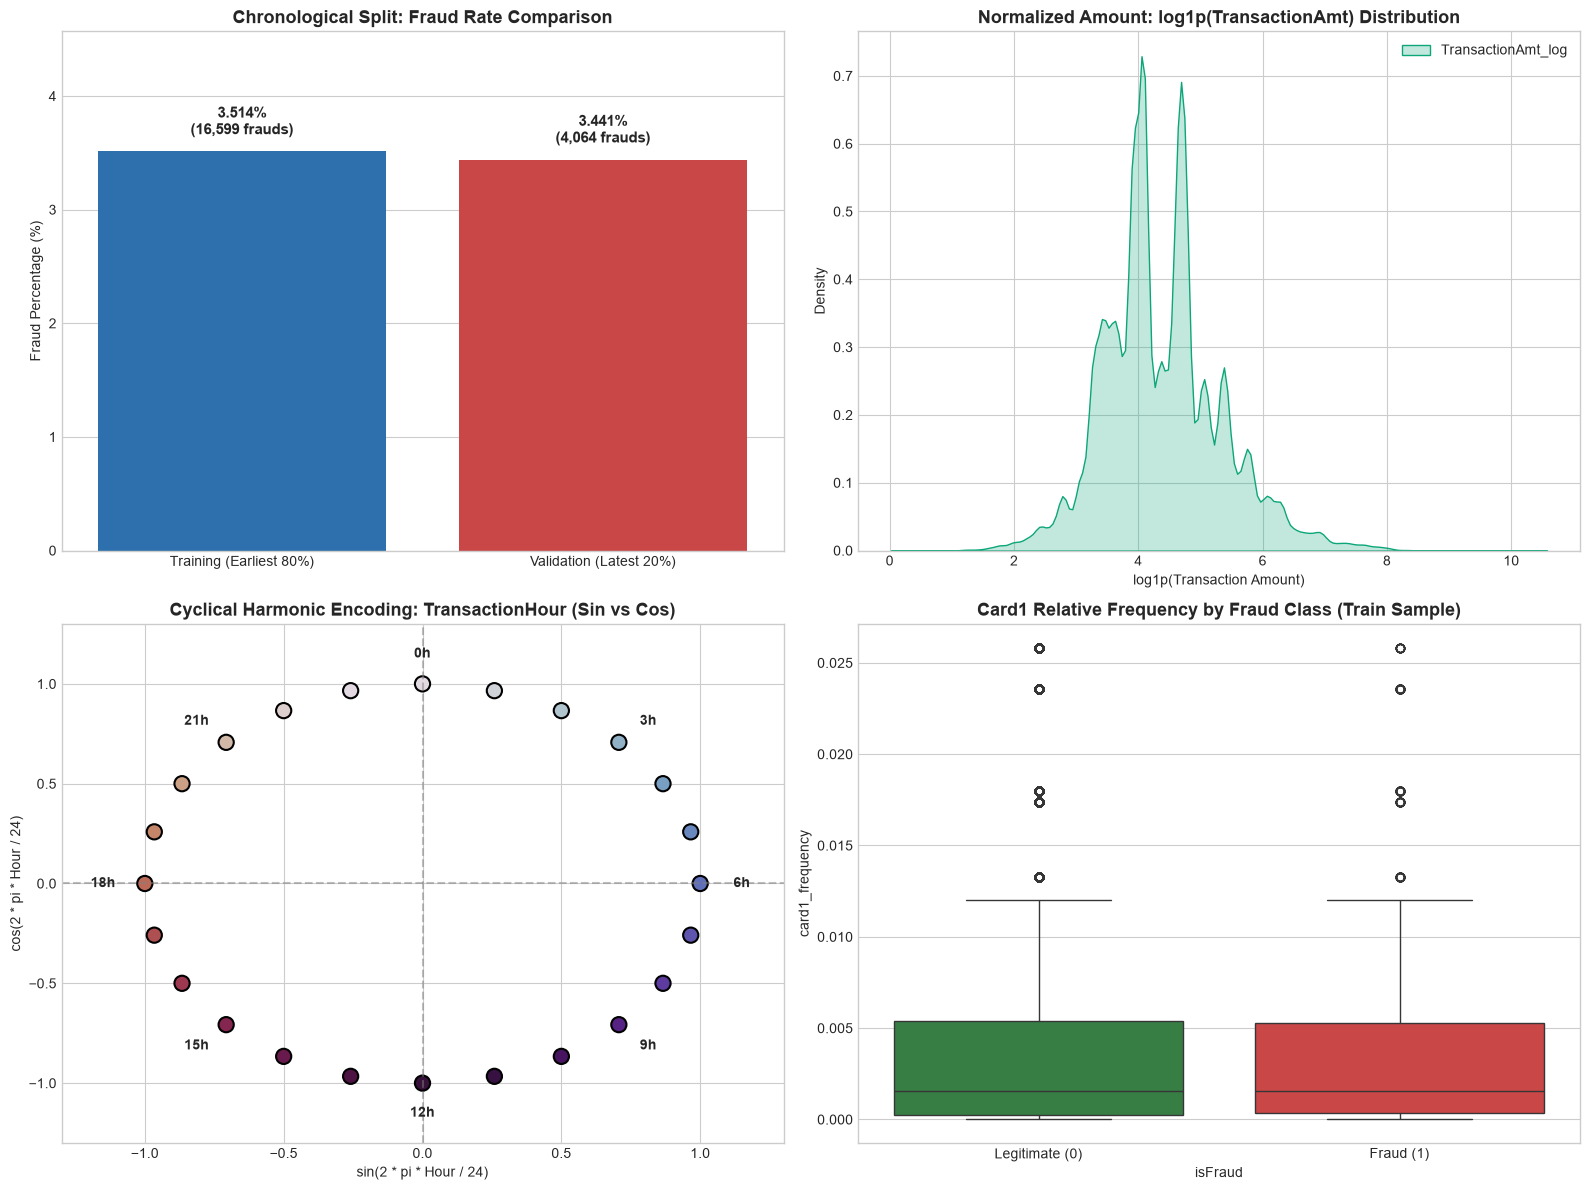

In [17]:
print("=" * 70)
print("SECTION 19: FEATURE ENGINEERING DIAGNOSTIC VISUALIZATIONS")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Train vs Validation Fraud Rate
splits = ['Training (Earliest 80%)', 'Validation (Latest 20%)']
fraud_rates = [train_fraud_pct, val_fraud_pct]
bar_colors = ['#1971c2', '#e03131']
sns.barplot(x=splits, y=fraud_rates, palette=bar_colors, ax=axes[0, 0])
axes[0, 0].set_title('Chronological Split: Fraud Rate Comparison', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Fraud Percentage (%)')
for i, v in enumerate(fraud_rates):
    axes[0, 0].text(i, v + 0.15, f"{v:.3f}%\n({[train_fraud, val_fraud][i]:,} frauds)", ha='center', fontsize=11, fontweight='semibold')
axes[0, 0].set_ylim(0, max(fraud_rates) * 1.3)

# 2. Transaction Amount: Raw vs Log1p
sns.kdeplot(train_df['TransactionAmt_log'], ax=axes[0, 1], color='#0ca678', fill=True, label='TransactionAmt_log')
axes[0, 1].set_title('Normalized Amount: log1p(TransactionAmt) Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('log1p(Transaction Amount)')
axes[0, 1].legend()

# 3. Cyclical Hour Representation (Polar/Scatter Circle)
sample_hours = train_df[['TransactionHour', 'TransactionHour_sin', 'TransactionHour_cos']].drop_duplicates().sort_values('TransactionHour')
axes[1, 0].scatter(sample_hours['TransactionHour_sin'], sample_hours['TransactionHour_cos'], 
                   c=sample_hours['TransactionHour'], cmap='twilight', s=120, edgecolors='black', linewidth=1.5)
for _, row in sample_hours.iloc[::3].iterrows():
    axes[1, 0].text(row['TransactionHour_sin'] * 1.15, row['TransactionHour_cos'] * 1.15, f"{int(row['TransactionHour'])}h", 
                    ha='center', va='center', fontsize=10, fontweight='bold')
axes[1, 0].set_title('Cyclical Harmonic Encoding: TransactionHour (Sin vs Cos)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('sin(2 * pi * Hour / 24)')
axes[1, 0].set_ylabel('cos(2 * pi * Hour / 24)')
axes[1, 0].set_xlim(-1.3, 1.3)
axes[1, 0].set_ylim(-1.3, 1.3)
axes[1, 0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].axvline(0, color='gray', linestyle='--', alpha=0.5)

# 4. Engineered Frequency Feature Distribution by Fraud Class
sns.boxplot(x='isFraud', y='card1_frequency', data=train_df.sample(min(50000, len(train_df)), random_state=RANDOM_STATE),
            palette=['#2b8a3e', '#e03131'], ax=axes[1, 1])
axes[1, 1].set_title('Card1 Relative Frequency by Fraud Class (Train Sample)', fontsize=13, fontweight='bold')
axes[1, 1].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
axes[1, 1].set_ylabel('card1_frequency')

plt.tight_layout()
fe_plot_path = os.path.join(proc_dir, 'feature_engineering_analysis.png')
plt.savefig(fe_plot_path, dpi=200)
print(f"Visualizations saved to: {fe_plot_path}")
plt.show()


In [18]:
print("=" * 70)
print("FINAL REPORT — PHASE 4 STEP 3: FEATURE ENGINEERING")
print("=" * 70)
print(f"1. Original Feature Count:          {initial_cols}")
print(f"2. Engineered Feature Count:        {len(model_features) + len(excluded_features) + 1 - initial_cols} features added")
print(f"3. Final Model Feature Count:       {len(model_features)}")
print(f"4. Excluded Feature Count:          {len(excluded_features)} (TransactionID quarantined)")
print(f"5. Training Rows:                   {train_len:,} ({train_len/(train_len + val_len)*100:.1f}%)")
print(f"6. Validation Rows:                 {val_len:,} ({val_len/(train_len + val_len)*100:.1f}%)")
print(f"7. Training Fraud %:                {train_fraud_pct:.3f}% ({train_fraud:,} positive cases)")
print(f"8. Validation Fraud %:              {val_fraud_pct:.3f}% ({val_fraud:,} positive cases)")
print(f"9. Number of Categorical Features:  {len(cat_columns)}")
print(f"10. Number of Numerical Features:   {len(model_features) - len(cat_columns)}")
print(f"11. Leakage Checks Passed/Failed:   PASSED (Zero lookahead; strictly chronological split; train-fitted frequencies)")
print(f"12. Output Files Created:")
print(f"    - {train_parquet_path} ({train_mb:.1f} MB)")
print(f"    - {val_parquet_path} ({val_mb:.1f} MB)")
print(f"    - {meta_csv_path}")
print(f"    - {model_feat_path}")
print(f"    - {excluded_feat_path}")
print(f"    - {quality_csv_path}")
print(f"    - {leakage_csv_path}")
print(f"    - {fe_plot_path}")
print(f"13. Notebook Execution Status:      SUCCESSFUL")
print("=" * 70)


FINAL REPORT — PHASE 4 STEP 3: FEATURE ENGINEERING
1. Original Feature Count:          445
2. Engineered Feature Count:        21 features added
3. Final Model Feature Count:       464
4. Excluded Feature Count:          1 (TransactionID quarantined)
5. Training Rows:                   472,432 (80.0%)
6. Validation Rows:                 118,108 (20.0%)
7. Training Fraud %:                3.514% (16,599 positive cases)
8. Validation Fraud %:              3.441% (4,064 positive cases)
9. Number of Categorical Features:  36
10. Number of Numerical Features:   428
11. Leakage Checks Passed/Failed:   PASSED (Zero lookahead; strictly chronological split; train-fitted frequencies)
12. Output Files Created:
    - ..\data\processed\train_features.parquet (71.5 MB)
    - ..\data\processed\validation_features.parquet (18.6 MB)
    - ..\data\processed\feature_metadata.csv
    - ..\data\processed\model_features.txt
    - ..\data\processed\excluded_features.txt
    - ..\data\processed\feature_qualit